## Naive Bayes

Naive Bayes es un algoritmo de clasificación basado en el teorema de Bayes con una suposición de independencia entre las características.

### Objetivo
Clasificar datos en diferentes categorías basándose en las probabilidades calculadas a partir de los datos de entrenamiento.

### Conceptos Claves:
- **Teorema de Bayes**: Proporciona una forma de calcular la probabilidad de una hipótesis dada la evidencia.
  $$
  P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}
  $$
- **Independencia condicional**: Supone que las características son independientes entre sí dado el resultado de la clase.
- **Probabilidad a priori**: La probabilidad inicial de una clase antes de observar los datos.
- **Probabilidad a posteriori**: La probabilidad de una clase después de observar los datos.

### Variables requeridas
Se requieren variables categóricas o continuas que puedan ser discretizadas.

### Hiperparámetros
Los modelos de Naive Bayes tienen diferentes variantes, cada una con sus propios hiperparámetros. Algunos de los más comunes son:

- **MultinomialNB** (para datos discretos como texto):
  - `alpha`: Parámetro de suavizado de Laplace/Lidstone. Evita probabilidades cero. Valores típicos son pequeños (ej., 1e-9 a 1).
  - `fit_prior`: Indica si se deben calcular las probabilidades a priori a partir de los datos o suponer que son iguales para todas las clases.

- **GaussianNB** (para datos continuos):
  - `var_smoothing`: Porcentaje de la varianza máxima de cada característica que se agrega a la varianza para la estabilidad numérica. Valores comunes son muy pequeños, como 1e-9.

- **ComplementNB** (para datos desbalanceados):
  - `alpha`: Igual que en `MultinomialNB`.
  - `norm`: Si se debe normalizar las probabilidades para cada característica.

- **CategoricalNB** (para variables categóricas puras):
  - `alpha`: Suavizado, igual que en `MultinomialNB`.

### Algoritmo
1. **Preparación de los datos**:
 Convertir los datos en un formato adecuado;
 
  -el algortimo asume que las características siguen una **distribución normal(Gaussiana)**  es bueno verificar  esta condición (ej: Shapiro.Wilk)  

  -No requiere extricatamente normalizar, sin embargo, en caso de escalas muy distintas, si aplica la estandarización.

2. **Cálculo de probabilidades a priori**: Calcular la probabilidad inicial de cada clase.
3. **Cálculo de probabilidades condicionales**: Calcular la probabilidad de cada característica dado cada clase.
4. **Aplicación del teorema de Bayes**: Utilizar el teorema de Bayes para calcular la probabilidad a posteriori de cada clase dado un conjunto de características.
5. **Clasificación**: Asignar la clase con la mayor probabilidad a posteriori al nuevo dato.

### Evaluación
Se puede evaluar mediante métricas como la precisión, la exactitud, la sensibilidad y la especificidad, y utilizando una matriz de confusión.


## Caso aplicado

In [1]:
# Importo librerias de operacion, transformación y visualización
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import shapiro # Pruebas estadistica
from sklearn.preprocessing import StandardScaler # Para estandarizar
from sklearn.model_selection import train_test_split # Dividir set entrenamiento y prueba
from sklearn.naive_bayes import GaussianNB # Algoritmo de ML
from sklearn.metrics import accuracy_score,recall_score,f1_score,precision_score,roc_auc_score # Metricas del modelo
from sklearn.datasets import load_breast_cancer # Data a utilizar

In [2]:
# Declaro dataset segmentado
x_cancer= pd.DataFrame(load_breast_cancer().data,columns = load_breast_cancer().feature_names)
y_cancer_type= load_breast_cancer().target

In [3]:
# Estadísticas descriptivas
print(x_cancer.describe())
print("Se exponen diversas escalas,\nesto puede afectar las estimaciones de probabilidad y reducir el rendimiento del modelo. ")

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [5]:
# Normalización de las características (X)
X_scaled = StandardScaler().fit_transform(x_cancer)
X_cancer_norm = pd.DataFrame(X_scaled, columns=x_cancer.columns)

In [6]:
# Verificación de la normalización
print(X_cancer_norm.describe().loc[['mean','std']])

       mean radius  mean texture  mean perimeter     mean area  \
mean -3.153111e-15 -6.568462e-15   -6.993039e-16 -8.553985e-16   
std   1.000880e+00  1.000880e+00    1.000880e+00  1.000880e+00   

      mean smoothness  mean compactness  mean concavity  mean concave points  \
mean     6.081447e-15     -1.136369e-15   -2.997017e-16         1.023981e-15   
std      1.000880e+00      1.000880e+00    1.000880e+00         1.000880e+00   

      mean symmetry  mean fractal dimension  ...  worst radius  worst texture  \
mean  -1.860648e-15           -1.504752e-15  ... -2.297713e-15   1.742016e-15   
std    1.000880e+00            1.000880e+00  ...  1.000880e+00   1.000880e+00   

      worst perimeter    worst area  worst smoothness  worst compactness  \
mean    -1.198807e-15  6.118909e-16     -5.094929e-15      -2.122887e-15   
std      1.000880e+00  1.000880e+00      1.000880e+00       1.000880e+00   

      worst concavity  worst concave points  worst symmetry  \
mean     6.118909e-16   

C:\Users\csolis\AppData\Local\Temp\ipykernel_8228\406102649.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="pastel")


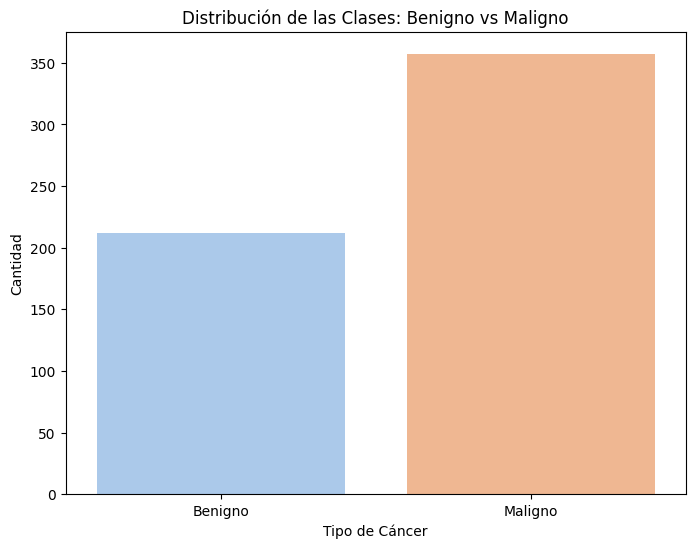

In [7]:
# Asegúrate de tener la columna `cancer_type` separada
cancer_type = pd.Series(y_cancer_type)

# Contar la frecuencia de cada clase
class_counts = cancer_type.value_counts()

# Visualización de la distribución de clases
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="pastel")
plt.title("Distribución de las Clases: Benigno vs Maligno")
plt.xlabel("Tipo de Cáncer")
plt.ylabel("Cantidad")
plt.xticks([0, 1], ['Benigno', 'Maligno'])

plt.show()

Dado que la distribución de la clase es "desequilibrada", Naive Bayes puede ser afectado si las probabilidades a priori no se reflejan en la distribucción real.

Dado que por la naturaleza de la data, es relevante clasificar bien a "Maligno", es importante fijarse en recall o F1-score (balance), si el modelo predice un falso negativoo el error es más grave.


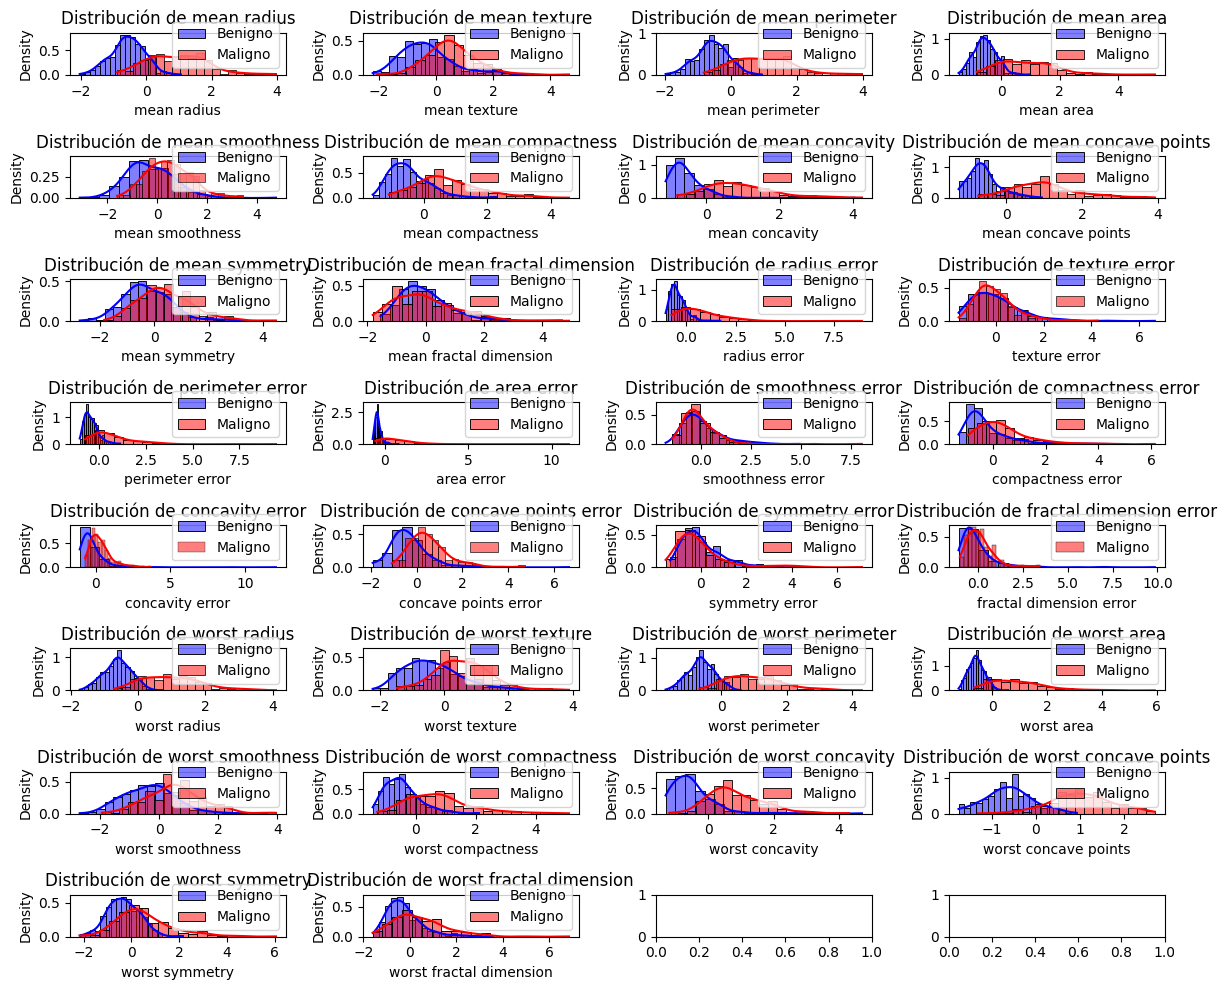

In [9]:
# Dividir en clases (Benigno y Maligno)
benign_class = X_cancer_norm[y_cancer_type == 1]
malignant_class = X_cancer_norm[y_cancer_type == 0]
# Visualización de la distribución de las características
fig, axes = plt.subplots(8, 4, figsize=(12, 10))
axes = axes.ravel()

for i, feature in enumerate(X_cancer_norm.columns):
    sns.histplot(benign_class[feature], kde=True, ax=axes[i], color="blue", label="Benigno", stat="density", bins=20)
    sns.histplot(malignant_class[feature], kde=True, ax=axes[i], color="red", label="Maligno", stat="density", bins=20)
    axes[i].set_title(f'Distribución de {feature}')
    axes[i].legend()

plt.tight_layout()
plt.show()

A pesar de aplicar una normalización, se puede observar que no se cumple con una distribucción normal  gaussiana, para confirmar lo anterior, se realizar test shapiro-wilk

In [17]:
import pandas as pd
from scipy.stats import shapiro

# Crear un DataFrame para almacenar los resultados
results = []

# Realizar la prueba de Shapiro-Wilk para cada característica
for feature in X_cancer_norm.columns:
    try:
        stat, p_value = shapiro(X_cancer_norm[feature])
        
        # Decisión sobre H₀
        if p_value > 0.05:
            normality = "NO se rechaza H₀,es normal"
        else:
            normality = "Se rechaza H₀, NO es normal"
        
        # Guardar el resultado en la lista
        results.append({
            'Característica': feature,
            'Estadístico': round(stat, 4),
            'p-valor': round(p_value, 4),
            'Resultado de la Prueba': normality
        })
    
    except Exception as e:
        # En caso de error (por ejemplo, datos constantes)
        results.append({
            'Característica': feature,
            'Estadístico': None,
            'p-valor': None,
            'Resultado de la Prueba': f"Error: {str(e)}"
        })

# Convertir los resultados a un DataFrame para una visualización más ordenada
results_df = pd.DataFrame(results)

# Mostrar los resultados
print(results_df)


             Característica  Estadístico  p-valor       Resultado de la Prueba
0               mean radius       0.9411   0.0000  Se rechaza H₀, NO es normal
1              mean texture       0.9767   0.0000  Se rechaza H₀, NO es normal
2            mean perimeter       0.9362   0.0000  Se rechaza H₀, NO es normal
3                 mean area       0.8584   0.0000  Se rechaza H₀, NO es normal
4           mean smoothness       0.9875   0.0001  Se rechaza H₀, NO es normal
5          mean compactness       0.9170   0.0000  Se rechaza H₀, NO es normal
6            mean concavity       0.8668   0.0000  Se rechaza H₀, NO es normal
7       mean concave points       0.8917   0.0000  Se rechaza H₀, NO es normal
8             mean symmetry       0.9726   0.0000  Se rechaza H₀, NO es normal
9    mean fractal dimension       0.9233   0.0000  Se rechaza H₀, NO es normal
10             radius error       0.7456   0.0000  Se rechaza H₀, NO es normal
11            texture error       0.8962   0.0000  S

Normalmente, en este caso se sugeriría evaluar otro modelo para los datos, 

In [22]:
X_log_transformed = x_cancer + 1  # Evitar log(0)
X_Cancer_log = np.log(X_log_transformed)
# Verificar las estadísticas después de la transformación
print(X_Cancer_log.describe().loc[['mean', 'std']])

      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
mean     2.691235      2.988199        4.500683   6.365109         0.091914   
std      0.222226      0.209417        0.248328   0.482274         0.012794   

      mean compactness  mean concavity  mean concave points  mean symmetry  \
mean          0.098145        0.082552             0.047095       0.166232   
std           0.046646        0.070113             0.036268       0.023036   

      mean fractal dimension  ...  worst radius  worst texture  \
mean                0.060883  ...      2.813668       3.257394   
std                 0.006615  ...      0.260391       0.231108   

      worst perimeter  worst area  worst smoothness  worst compactness  \
mean         4.641377    6.617350          0.124110           0.219380   
std          0.288172    0.554173          0.020091           0.117392   

      worst concavity  worst concave points  worst symmetry  \
mean         0.228383              0.10679

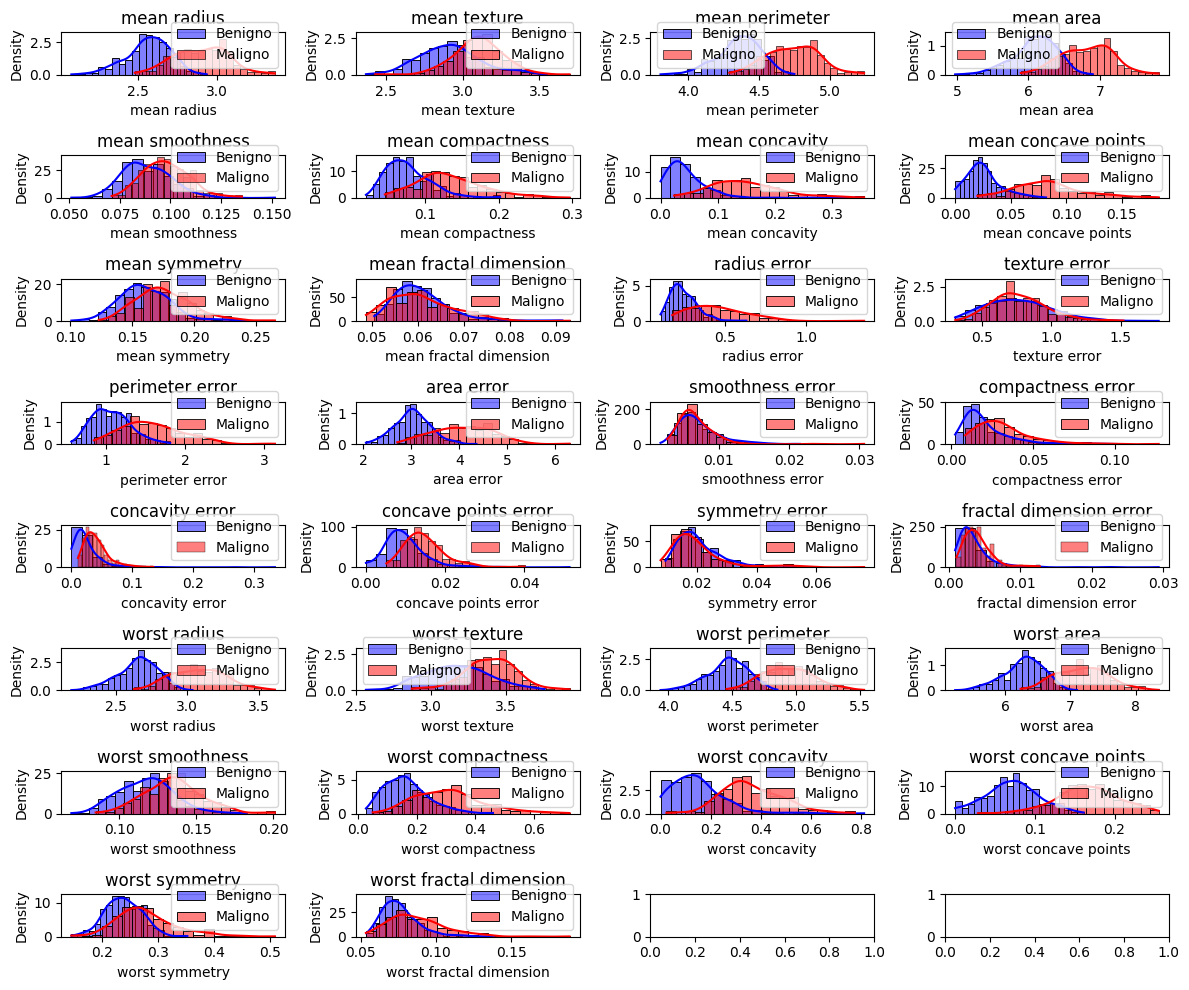

In [27]:
# Dividir en clases (Benigno y Maligno)
benign_class = X_Cancer_log[y_cancer_type == 1]
malignant_class = X_Cancer_log[y_cancer_type == 0]
# Visualización de la distribución de las características
fig, axes = plt.subplots(8, 4, figsize=(12, 10))
axes = axes.ravel()

for i, feature in enumerate(X_Cancer_log.columns):
    sns.histplot(benign_class[feature], kde=True, ax=axes[i], color="blue", label="Benigno", stat="density", bins=20)
    sns.histplot(malignant_class[feature], kde=True, ax=axes[i], color="red", label="Maligno", stat="density", bins=20)
    axes[i].set_title(f'{feature}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Dividimos el DF en entrenamiento y prueba
X = cancer
Y = cancer_type

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [ ]:
# Crear y entrenar el modelo Naive Bayes
model = GaussianNB()


In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Crear el modelo Naive Bayes
model = GaussianNB()

# Definir los parámetros a ajustar
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

# Búsqueda de hiperparámetros con validación cruzada
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='f1_weighted', cv=5)
grid_search.fit(X_train, y_train)

# Mejor modelo encontrado
best_model = grid_search.best_estimator_

# Predicción en el conjunto de prueba
y_pred = best_model.predict(X_test)

# Evaluación del modelo
print("Mejores Hiperparámetros:", grid_search.best_params_)

# Usar los nombres de clase correctos para el reporte
target_names = ['Maligno', 'Benigno']
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred, target_names=target_names))
print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))

Mejores Hiperparámetros: {'var_smoothing': 1e-09}

Reporte de Clasificación:
               precision    recall  f1-score   support

     Maligno       0.93      0.90      0.92        42
     Benigno       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

Matriz de Confusión:
 [[38  4]
 [ 3 69]]


In [ ]:
model.fit(X_train, y_train)

In [10]:
model.fit(X_train,y_train)

GaussianNB()

In [11]:
labels = model.predict(X_test)

Text(113.9222222222222, 0.5, 'predicted label')

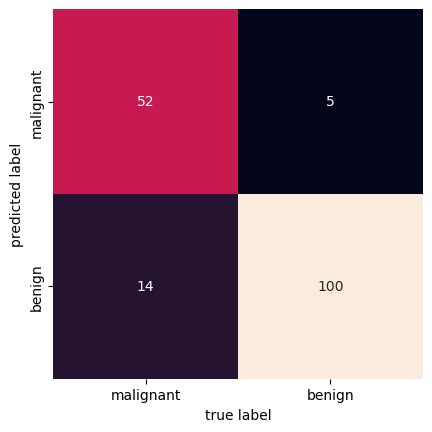

In [12]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(y_test, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=load_breast_cancer().target_names, yticklabels=load_breast_cancer().target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')

In [14]:
print(f'precision: {precision_score(labels,y_test)}')
print(f'recall: {recall_score(labels,y_test)}')
print(f'accuracy: {accuracy_score(labels,y_test)}')
print(f'f1 score: {f1_score(labels,y_test)}')

precision: 0.9523809523809523
recall: 0.8771929824561403
accuracy: 0.8888888888888888
f1 score: 0.91324200913242
